# Lecture 07: Automatic differentiation for DEQNs

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §2.7 (Automatic differentiation), §Appendix B (Matrix calculus)  
**Notebook role:** core  
**Author:** Simon Scheidegger  


In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


In [ ]:
# Chapter-wide RUN_MODE budget helper -- maps RUN_MODE to a training budget.
_BUDGET = {
    "smoke":      (501,    501),    # quick CI sweep
    "teaching":  (20001,  2001),   # default teaching run
    "production": (40001,  5001),  # publication run
}
EP_UNIFORM, EP_SIM = _BUDGET[RUN_MODE]
print(f"RUN_MODE={RUN_MODE!r}: EP_UNIFORM={EP_UNIFORM}, EP_SIM={EP_SIM}")


# Deep Equilibrium Nets via Automatic Differentiation

## Notebook 3: stochastic Brock-Mirman with `tf.GradientTape`

### Purpose
This notebook is the stochastic counterpart of **notebook 02**. We solve the Brock-Mirman model with AR(1) total-factor-productivity and partial depreciation $\delta = 0.1$, but we replace the hand-derived FOC + envelope theorem by two `tf.GradientTape` calls on a single primitive `Pi(K_in, K_out, z_in)`. Here `K_in` is today's *capital state*, `K_out` is the *choice* (tomorrow's capital), and `z_in` is the *exogenous shock*.

### Model (recap of notebook 02)
$$\max_{\{C_t\}} \;\mathbb{E}\!\left[ \sum_{t=0}^{\infty} \beta^t \ln(C_t) \right] \quad \text{s.t.}\quad K_{t+1} + C_t = Y_t + (1-\delta)K_t,\;\; Y_t = z_t K_t^{\alpha},\;\; \log z_{t+1} = \rho \log z_t + \sigma \epsilon_{t+1}.$$
The state is $\mathbf{X}_t = (z_t, K_t)$, the policy is $K_{t+1}=g(\mathbf{X}_t)$. Recursively,
$$V(z_t, K_t) = \max_{K_{t+1}} \;\underbrace{\ln\!\big(\,z_t K_t^{\alpha} + (1-\delta)K_t - K_{t+1}\big)}_{=\,\Pi(K_t,K_{t+1},z_t)} + \beta\,\mathbb{E}\!\left[V(z_{t+1}, K_{t+1})\right].$$

### Why pen-and-paper FOC + envelope are no longer needed
With period payoff
$$\Pi(K_{\text{in}},\,K_{\text{out}},\,z_{\text{in}}) \;=\; u\!\big(\,Y(K_{\text{in}},z_{\text{in}}) + (1-\delta)K_{\text{in}} - K_{\text{out}}\,\big),$$
we apply the **same autodiff notation as in notebook 02**:

> **Notation — what do $\partial_1\Pi$ and $\partial_2\Pi$ mean here?**
> The subscript names the *slot being differentiated*, not a time index. `Pi` now has three slots, but we only ever differentiate slots 1 and 2:
> - $\partial_1 \Pi \;=\; \dfrac{\partial \Pi}{\partial K_{\text{in}}}$  — derivative w.r.t. the **1st argument** of `Pi`, i.e. the *capital state*.
> - $\partial_2 \Pi \;=\; \dfrac{\partial \Pi}{\partial K_{\text{out}}}$ — derivative w.r.t. the **2nd argument** of `Pi`, i.e. the *capital choice*.
> The shock $z_{\text{in}}$ sits in slot 3 and is treated as an exogenous parameter inside the tape, not differentiated.
>
> So $\partial_2\Pi(K_t,K_{t+1},z_t)$ differentiates in slot 2, evaluated at $(K_t,K_{t+1},z_t)$, giving $\partial\Pi/\partial K_{t+1}$.
> $\partial_1\Pi(K_{t+1},K_{t+2},z_{t+1})$ differentiates in slot 1, evaluated at $(K_{t+1},K_{t+2},z_{t+1})$, giving $\partial\Pi/\partial K_{t+1}$ (different slot, *same* physical variable).

The hand vs. autodiff correspondence:

| | Hand derivation (notebook 02) | Autodiff |
|---|---|---|
| FOC w.r.t. the *choice* $K_{t+1}$ | $-u'(C_t) + \beta\, \mathbb{E}[V'(z_{t+1},K_{t+1})] = 0$ | $\partial_2 \Pi(K_t, K_{t+1}, z_t) \equiv \dfrac{\partial \Pi}{\partial K_{\text{out}}}\Big|_{(K_t,K_{t+1},z_t)}$ via `tape.gradient` |
| Envelope: $V'(K_t,z_t)$ at the *state* $K_t$ | $u'(C_t)\,(\alpha z_t K_t^{\alpha-1} + 1 - \delta)$ | $\partial_1 \Pi(K_t, K_{t+1}, z_t) \equiv \dfrac{\partial \Pi}{\partial K_{\text{in}}}\Big|_{(K_t,K_{t+1},z_t)}$ via `tape.gradient` |

Substituting the envelope at $K_{t+1}$ into the FOC delivers the **autodiff stochastic Euler residual**
$$\boxed{\;\underbrace{\partial_2 \Pi(K_t, K_{t+1}, z_t)}_{\text{derivative w.r.t. }K_{t+1}\text{ (the choice)}} \;+\; \beta\,\mathbb{E}_{z_{t+1}\,|\,z_t}\!\left[\underbrace{\partial_1 \Pi(K_{t+1}, K_{t+2}, z_{t+1})}_{\text{derivative w.r.t. }K_{t+1}\text{ (now the state of }t+1\text{)}}\right] \;=\; 0\;}$$
The expectation is approximated by Gauss-Hermite quadrature (5 nodes), exactly as in notebook 02. Only the user-written piece of the loss changes: now it is just `Pi`.

### What we will verify
1. **Cross-check vs the hand-derived residual** of notebook 02, to machine precision ($\sim 10^{-6}$ in float32). Confirms the autodiff loss *is* the same Euler equation.
2. **Side-experiment vs an analytical solution**: under full depreciation $\delta=1$, the stochastic Brock-Mirman model with log utility has the closed-form policy $K_{t+1} = \alpha\beta\,z_t K_t^{\alpha}$. We re-train a small network in this regime and compare to the closed form.

> **Why this matters.** The pattern $\,\partial_2 \Pi + \beta\,\mathbb{E}[\partial_1 \Pi] = 0\,$ (derivative w.r.t. the choice slot, plus $\beta$ times expectation of derivative w.r.t. the state slot) is the autodiff template for *any* recursive optimization problem with a single control. Change the utility, the production function, or the depreciation law inside `Pi`, and nothing else in the loss code needs to change. This is the practical reason Deep Equilibrium Nets scale so well to high-dimensional macro models.

In [1]:
# Import necessary liblaries
import numpy as np
import math
import tensorflow as tf
from tensorflow import keras

import matplotlib.pyplot as plt
from matplotlib import rc
plt.rcParams["font.size"] = 15

%matplotlib inline

print("Version of tensorflow is {}".format(tf.__version__))

2026-04-22 08:35:39.345976: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776839739.380342    8357 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776839739.391057    8357 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-22 08:35:39.424682: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Version of tensorflow is 2.18.0


### Evaluating the expectation operator
In this section we define the integration nodes and weights we will use to evaluate the expectation operator.  
We choose ```n_int``` integration points, denote the integration nodes by ```x_int_norm```, and the weights by ```w_int``` and obtain them using [```np.polynomial.hermite.hermgauss```](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.hermite.hermgauss.html).  
The actual integration nodes we use later will be multiplied with the standard deviation of the innovations.

2026-04-22 08:35:42.968520: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


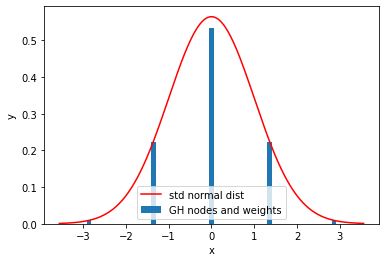

sum(w_int) =  1.0000001


In [2]:
n_int = 5 # integration nodes
x_int_norm, w_int = np.polynomial.hermite.hermgauss(n_int) # obtain standard GH nodes and weights
w_int = w_int / np.sqrt(np.pi) # divide the weights by sqrt(pi)
x_int_norm = x_int_norm * np.sqrt(2) # multiply weights with 2**0.5

#convert to tensorflow
x_int_norm = tf.constant(x_int_norm, dtype = tf.float32)
w_int = tf.constant(w_int, dtype = tf.float32)

# for plotting the normal distribution
x_plot_norm = np.linspace(np.min(x_int_norm) - 0.7, np.max(x_int_norm) + 0.7, 200)
y_plot_norm = np.exp(- 0.5 * x_plot_norm ** 2) / np.sqrt(np.pi)

plt.bar(x_int_norm, w_int, width = 0.1, label = "GH nodes and weights")
plt.plot(x_plot_norm, y_plot_norm, color = "r", label = "std normal dist")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# we should make sure the weights some to 1
print("sum(w_int) = ", np.sum(w_int))

### Implementing the loss function

We define the economic parameters, which are constant throughout and will be globals in this notebook.

In [3]:
alpha = 0.36  # Capital share in the Cobb-Douglas production function
beta = 0.99  # Discount factor
delta = 0.1 # depreciation of capital
sigma_tfp = 0.04 # std. dev. for tfp process innvoations
rho_tfp = 0.9 # persistence of tfp process
x_int = x_int_norm * sigma_tfp # adjust the integration nodes

Since this model can be solved analytically for the full depreciation case, we implement the analytical solution (so that we can later check the solution found by the neural network).

In [4]:
def k_compute_infty(alpha, beta):
    """ Return the stationary point (or steady state) for full depreciation """
    return (1 / (beta * alpha))**(1/(alpha - 1))

k_infty = k_compute_infty(alpha, beta)
print("Stationary point is {:5f}".format(k_infty))


def Kplus_compute_analytic(K, alpha, beta):
    """ Return the optimal capital stock in the next period  for full depreciation """
    return alpha * beta * K**alpha


def c_compute(K, Knext, alpha, beta):
    """ Return the optimal consumption policy  for full depreciation """
    return Knext**alpha - Knext

Stationary point is 0.199482


#### Deep neural network 

In this section, we define the architecture of the deep neural net.  
Our goal is for the neural network to approximate the savings rate $s_t$, such that $K_{t+1} = Y_t s_t \approx Y_t \mathcal{N}\left(K_t \right)$.  
The neural network input is hence a now 2-dimensional state $\mathbf{X}_t = [z_t, K_t]$ and the output is the 1-dimesnional savings rate $s_t$.

##### Hyper parameters

* Hyper parameter defines the architecture of the deep neural net. 

* Note that the purpose of this notebook is in the demonstration of the deep neural net. Detail analyses of the choice of hyper parameters are omitted and we use a densely connected feed forward neural network with two hidden layers as in [Azinovic et al. (2022)](https://onlinelibrary.wiley.com/doi/full/10.1111/iere.12575). Since we are approximating the savings rate, we want our architecture to ensure that $s_t \in (0, 1)$. We can do this by using a [sigmoid activation function](https://towardsdatascience.com/activation-functions-neural-networks-1cbd9f8d91d6) in the output layer. This is in the spirit of encoding prior knowledge based on economics directly into the neural network architecture (relatedly, [Kahou et al. (2021)](https://www.nber.org/papers/w28981) and [Han et al. (2022)](https://arxiv.org/abs/2112.14377) show how symmetry can be encoded into the neural-network architecture and [Azinovic and Žemlička (2023)](https://arxiv.org/abs/2303.14802) introduce market clearing neural network architectures.).  We assume the following structure of layers and activation functions: 
    * Layer 1: the input layer, 2 neurons corresponding to the tfp value $z_t$ and the capital stock $K_t$  
    * Layer 2: the first hidden layer, 50 neurons and is activated by Relu  
    * Layer 3: the second hidden layer, 50 neurons and is activated by Relu  
    * Layer 4: the output layer, 1 neuron corresponding to the savings rate $s_t$, such that $K_{t+1}=(1 - \delta) K_t + Y_t s_t$. We use a [sigmoid activation function](https://towardsdatascience.com/activation-functions-neural-networks-1cbd9f8d91d6), ensuring that $s_t \in (0, 1)$.

In [5]:
# Layer setting
num_input = 2
num_hidden1 = 50
num_hidden2 = 50
num_output = 1
layers_dim = [num_input, num_hidden1, num_hidden2, num_output]
print("Dimensions of each layer are {}".format(layers_dim))

Dimensions of each layer are [2, 50, 50, 1]


##### We define the neural network
We use [Keras](https://www.tensorflow.org/guide/keras) to define the neural network

##### Hard vs. soft constraints — the central design choice in DEQNs

Two kinds of equilibrium conditions appear in any dynamic stochastic model:

- **Inequality / feasibility constraints** — e.g.\ $C_t > 0$, $K_{t+1} > 0$,
  the resource constraint $C_t + K_{t+1} = Y_t$. These must hold *exactly*.
- **Optimality conditions** — e.g.\ the Euler equation. These hold in the
  equilibrium but not at every intermediate guess of the policy.

Azinovic, Gaegauf & Scheidegger (2022, §4.2.2; lecture script Fig. 2.3)
make this distinction explicit and treat the two kinds very differently:

| | Hard constraint (architecture) | Soft constraint (loss) |
|--|--|--|
| **What** | Built into the network output | Penalised in the cost function |
| **How** | Activation choice + algebraic identities | Squared residuals in $\mathcal{L}$ |
| **Cost** | Always satisfied — even at random init | Only satisfied at convergence |

**Why this matters here.** The cell below parameterises the savings *share*
$s_t \in (0, 1)$ via a **sigmoid** output. Combined with the resource
constraint $K_{t+1} = s_t Y_t$ and $C_t = (1 - s_t) Y_t$, this **guarantees
$C_t > 0$ and $K_{t+1} > 0$ simultaneously**, at every iteration of
training. We never have to penalise infeasibility — the architecture
rules it out. The Euler equation, by contrast, is enforced softly through
the loss.

This split removes a whole class of bad local minima (network outputs that
would imply $C_t < 0$) and is one reason DEQNs converge in regions where
naive penalty methods do not.

In [6]:
# we use sigmod in the output layer so output is between 0 and 1
nn = keras.Sequential([
    keras.layers.Dense(num_hidden1, activation='relu', input_shape=(num_input,)),
    keras.layers.Dense(num_hidden2, activation='relu'),
    keras.layers.Dense(num_output, activation='sigmoid')
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
print(nn.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,751 (10.75 KB)

 Trainable params: 2,751 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

None


##### The batch dimension
Since neural networks are highly parallelizable, we typically do not want to evaluate the neural network for only a single state $\mathbf{X} \in \mathbb{R}^2$, but for a matrix of $N_{data}$ different states $X \in \mathbb{R}^{N_{data}\times 2}$. The output of the neural network is then a vector $\mathbf{s}\in \mathbb{R}^{N_{data}\times 1}$.  
The convention in deep learning is to have the different data samples on the 0-axis.

In [8]:
# test it
X_test = np.array([[1., 1.], [0.5, 2.]])

print("X_test = ", X_test)
print("nn prediction = ", nn(X_test))

X_test =  [[1.  1. ]
 [0.5 2. ]]
nn prediction =  tf.Tensor(
[[0.5460455 ]
 [0.58280224]], shape=(2, 1), dtype=float32)


### Implementing the autodiff cost function

We build the cost in two steps.

**Step A, write the period payoff `Pi(K_in, K_out, z_in)`.** This is the only place the model enters the loss. Change $u$, $Y$, or $\delta$ here, and nothing else moves.

**Step B, compute the Euler residual via two `tf.GradientTape` calls** on `Pi` (recall: subscript = *slot of* `Pi`):
- one to get $\partial_2 \Pi(K_t, K_{t+1}, z_t) \equiv \partial\Pi/\partial K_{\text{out}}$ at $(K_t, K_{t+1}, z_t)$, the **FOC term** (derivative w.r.t. the choice slot).
- one to get $\partial_1 \Pi(K_{t+1}, K_{t+2}, z_{t+1}) \equiv \partial\Pi/\partial K_{\text{in}}$ inside the expectation at $(K_{t+1}, K_{t+2}, z_{t+1})$, the **envelope term** (derivative w.r.t. the state slot).

The Gauss-Hermite quadrature is used to evaluate $\mathbb{E}_{z_{t+1}|z_t}[\cdot]$ exactly as in notebook 02.

In [9]:
# ---- The ONLY model primitive the user writes ----
def Pi(K_in, K_out, z_in):
    """Period payoff: Pi(state K, choice K_out, exogenous shock z) = u(C).

    Slot 1 (K_in)  = today's capital (STATE)    --> differentiated by partial_1 Pi.
    Slot 2 (K_out) = tomorrow's capital (CHOICE) --> differentiated by partial_2 Pi.
    Slot 3 (z_in)  = exogenous shock            --> NOT differentiated (parameter).
    Change u, Y, or delta here; the rest of the loss is unchanged.
    """
    Y = z_in * K_in ** alpha
    C = Y + (1.0 - delta) * K_in - K_out
    return tf.math.log(C)


In [10]:
# Quick sanity check on Pi
K_test_in  = tf.constant([[1.0], [5.0], [10.0]])
K_test_out = tf.constant([[0.8], [4.0], [9.0]])
z_test     = tf.constant([[1.0], [1.0], [1.0]])
print("Pi(K_in, K_out, z) =", Pi(K_test_in, K_test_out, z_test).numpy().flatten())


Pi(K_in, K_out, z) = [0.09531009 0.8263499  0.8289307 ]


Now we wrap two tape.gradient calls around `Pi`. The expectation \(\mathbb{E}_{z_{t+1}|z_t}\) is approximated by Gauss-Hermite, identical to notebook 02.

In [11]:
@tf.function
def compute_cost(X, nn):
    """Mean squared error in the autodiff stochastic Euler equation.

    No FOC and no envelope theorem on paper. Both come out of `tf.GradientTape`.
    """
    n_data    = X.shape[0]
    dim_state = X.shape[1]

    # Read the state
    Z_t = X[:, 0:1]
    K_t = X[:, 1:2]

    # Forward roll: K_{t+1} via the network
    Y_t   = Z_t * K_t ** alpha
    s_t   = nn(X)
    K_tp1 = (1.0 - delta) * K_t + Y_t * s_t
    C_t   = Y_t - Y_t * s_t

    # ---- FOC term = partial_2 Pi = d Pi / d K_out, evaluated at (K_in=K_t, K_out=K_{t+1}, z_in=z_t).
    # So the tape differentiates Pi(K_t, K_tp1, Z_t) w.r.t. its SECOND argument K_tp1.
    # Mathematically equals -u'(C_t) -- but we never write u'.
    with tf.GradientTape() as tape_foc:
        tape_foc.watch(K_tp1)
        pi_t = Pi(K_t, K_tp1, Z_t)
    dPi_dKout = tape_foc.gradient(pi_t, K_tp1)

    # ---- Envelope term under expectation:
    # E_{z_{t+1}|z_t}[ partial_1 Pi = d Pi / d K_in at (K_in=K_{t+1}, K_out=K_{t+2}, z_in=z_{t+1}) ]
    # i.e. the tape differentiates Pi(K_tp1, K_tp2, Z_tp1) w.r.t. its FIRST argument K_tp1.
    # By the envelope theorem at the optimum, this equals E[V'(z_{t+1}, K_{t+1})].
    expectation = tf.zeros((n_data, 1))
    for i in range(n_int):
        innovation_i = x_int[i]
        Z_tp1   = tf.exp(rho_tfp * tf.math.log(Z_t) + innovation_i)
        X_tp1   = tf.concat([Z_tp1, K_tp1], axis=1)
        Y_tp1   = Z_tp1 * K_tp1 ** alpha
        s_tp1   = nn(X_tp1)
        K_tp2   = (1.0 - delta) * K_tp1 + Y_tp1 * s_tp1
        with tf.GradientTape() as tape_env:
            tape_env.watch(K_tp1)
            pi_tp1 = Pi(K_tp1, K_tp2, Z_tp1)
        dPi_dKin   = tape_env.gradient(pi_tp1, K_tp1)
        expectation = expectation + w_int[i] * dPi_dKin

    # Euler residual: FOC + beta * E[envelope]
    euler_res = dPi_dKout + beta * expectation

    cost = tf.reduce_mean(euler_res ** 2)
    LHS  = -dPi_dKout         # corresponds to 1/C_t (i.e. -partial_2 Pi = -d Pi / d K_out)
    RHS  =  beta * expectation
    r_t  = alpha * Z_t * K_t ** (alpha - 1.0)
    return cost, euler_res, C_t, K_tp1, r_t, LHS, RHS


In [12]:
# Quick test
X = tf.constant([[0.5, 1.], [0.9, 2.], [1.1, 3.]])
print("cost      = ", compute_cost(X, nn)[0].numpy())
print("euler_res = ", compute_cost(X, nn)[1].numpy().flatten())


cost      =  0.02017601
euler_res =  [-0.2055111   0.07050323  0.1154232 ]


#### Gradients
Now we define a function that, for given data X, computes the gradient of the loss w.r.t. the neural network parameters.  
This gradient will be used to update the neural network parameters into the direction which decreases the loss function.

In [13]:
def grad(X, nn):
    with tf.GradientTape() as tape:
        loss_value = compute_cost(X, nn)[0]
    return loss_value, tape.gradient(loss_value, nn.trainable_variables)

In [14]:
X = tf.constant([[1., 0.8], [2., 1.3], [0.5, 3.]])

loss, grads = grad(X, nn)

print("loss = ", loss)
print("grads = ", grads)

loss =  tf.Tensor(0.060121726, shape=(), dtype=float32)
grads =  [<tf.Tensor: shape=(2, 50), dtype=float32, numpy=
array([[-1.57539174e-03,  1.09306686e-02,  0.00000000e+00,
        -7.13390857e-03,  3.93256806e-02,  0.00000000e+00,
         1.79162379e-02,  0.00000000e+00, -6.41775951e-02,
         6.05437439e-03,  0.00000000e+00,  1.88898761e-02,
        -1.28031690e-02, -2.57999301e-02,  1.01860613e-02,
        -1.21265240e-02,  0.00000000e+00, -2.62226840e-03,
        -1.46079715e-03, -5.42197116e-02,  0.00000000e+00,
         4.73903492e-06, -3.39886621e-02,  0.00000000e+00,
         0.00000000e+00,  8.82970318e-02,  4.81916592e-04,
         8.12391751e-04,  3.77856046e-02, -1.78400874e-02,
         4.64404598e-02, -3.12516019e-02,  0.00000000e+00,
        -4.01208177e-03,  9.59562138e-04, -3.95944305e-02,
         3.76114920e-02, -1.78161655e-02, -4.42259572e-02,
         0.00000000e+00,  1.60085633e-02, -1.04125869e-03,
         0.00000000e+00,  3.22668627e-02, -2.88931094e-03,


#### Optimizer
We now define an optimizer, essentially an improved version of SGD

In [15]:
learning_rate = 0.0003
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

### Cross-check 1: autodiff vs hand-derived stochastic Euler residual

The hand-derived residual from notebook 02 is
$$r^{\text{hand}}(\mathbf{X}_t) \;=\; -\frac{1}{C_t} + \beta\,\mathbb{E}\!\left[\,\frac{1}{C_{t+1}}\,(1 - \delta + r_{t+1})\,\right].$$
The autodiff residual is mathematically identical. The cell below evaluates both on the **same network** and reports the maximum absolute difference. We expect machine-precision agreement (~$10^{-6}$ in float32).

In [16]:
# Hand-derived stochastic residual (from notebook 02) for verification only
@tf.function
def euler_residual_hand(X, nn):
    Z_t = X[:, 0:1]
    K_t = X[:, 1:2]
    Y_t = Z_t * K_t ** alpha
    s_t = nn(X)
    K_tp1 = (1.0 - delta) * K_t + Y_t * s_t
    C_t = Y_t - Y_t * s_t
    expectation = tf.zeros((X.shape[0], 1))
    for i in range(n_int):
        Z_tp1 = tf.exp(rho_tfp * tf.math.log(Z_t) + x_int[i])
        X_tp1 = tf.concat([Z_tp1, K_tp1], axis=1)
        Y_tp1 = Z_tp1 * K_tp1 ** alpha
        s_tp1 = nn(X_tp1)
        C_tp1 = Y_tp1 - s_tp1 * Y_tp1
        r_tp1 = alpha * Z_tp1 * K_tp1 ** (alpha - 1.0)
        inside = (1.0 / C_tp1) * (1.0 - delta + r_tp1)
        expectation = expectation + w_int[i] * inside
    return -1.0 / C_t + beta * expectation

# Compare on a grid
Z_grid = tf.constant(np.tile(np.linspace(0.8, 1.2, 5).reshape(-1,1), (5, 1)), dtype=tf.float32)
K_grid = tf.constant(np.repeat(np.linspace(1.0, 11.0, 5).reshape(-1,1), 5, axis=0), dtype=tf.float32)
X_grid = tf.concat([Z_grid, K_grid], axis=1)
res_auto = compute_cost(X_grid, nn)[1]
res_hand = euler_residual_hand(X_grid, nn)
max_abs_diff = tf.reduce_max(tf.abs(res_auto - res_hand)).numpy()
print(f"max | autodiff residual  -  hand-derived residual | = {max_abs_diff:.3e}")
print("--> Machine precision: autodiff has not changed the math, only how it is computed.")


max | autodiff residual  -  hand-derived residual | = 8.106e-06
--> Machine precision: autodiff has not changed the math, only how it is computed.


## Sampling data exogenously
we make a function to generate training data.
Here we just sample exogenously from an interval.

In [17]:
def get_training_data(z_lb, z_ub, k_lb, k_ub, n_data):
    
    Z = tf.random.uniform(
        shape = [n_data, 1],
        minval=z_lb,
        maxval=z_ub,
        dtype=tf.dtypes.float32)
    
    
    K = tf.random.uniform(
        shape = [n_data, 1],
        minval=k_lb,
        maxval=k_ub,
        dtype=tf.dtypes.float32)
    
    X = tf.concat([Z, K], axis = 1)
    return X

## Training
We iterataively generate training data and update the neural network

> **Convention note.** This notebook reports the autodiff Euler residual in **absolute** form `-1/C_t + beta * E[ (1/C_{t+1}) (1 - delta + r_{t+1}) ]`, while notebook `lecture_03_02_Brock_Mirman_Uncertainty_DEQN.ipynb` and the script's eq. `eq:ree_bm` report the **relative** form `1 - 1 / (C_t * beta * E[...])`. The two are related by an overall factor of `C_t`; the absolute form is used here because it isolates float-precision arithmetic for the autodiff-vs-hand cross-check, while the relative form is the natural diagnostic for the trained-policy comparison.

#=================================================================
episode = 0, loss [log10] = -1.6552916765213013


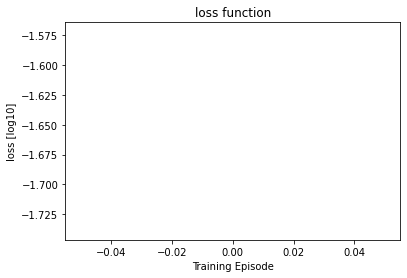

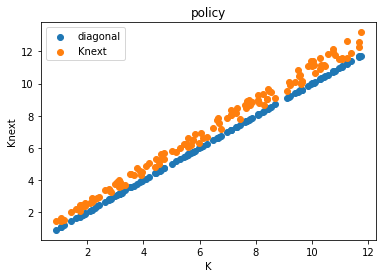

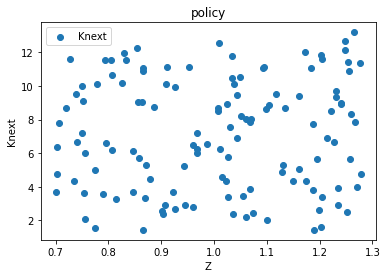

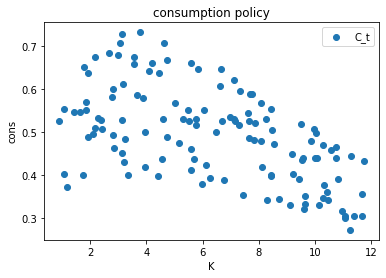

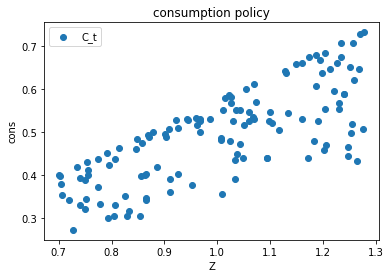

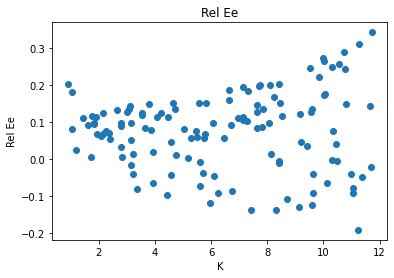

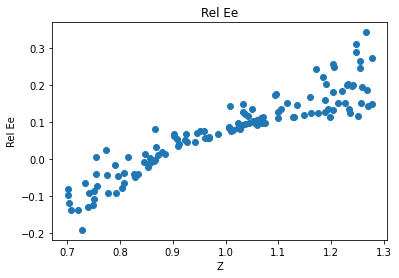

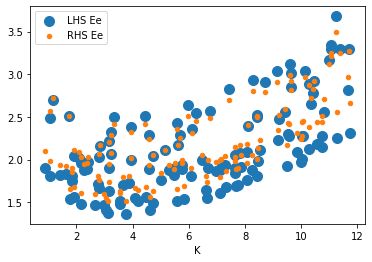

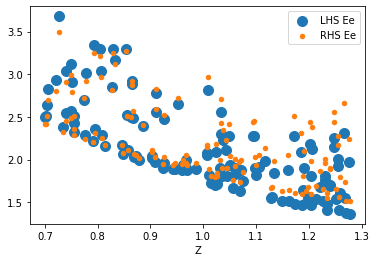

#=================================================================
episode = 1000, loss [log10] = -3.775663375854492


#=================================================================
episode = 2000, loss [log10] = -4.018899917602539


#=================================================================
episode = 3000, loss [log10] = -4.301812171936035


#=================================================================
episode = 4000, loss [log10] = -4.57758903503418


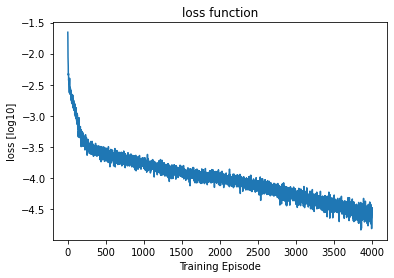

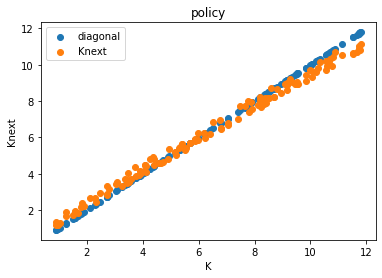

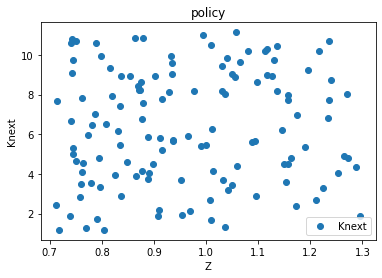

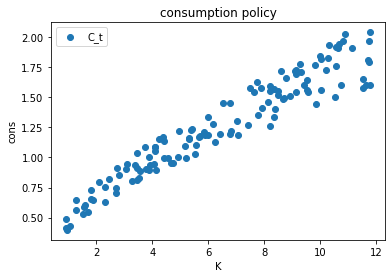

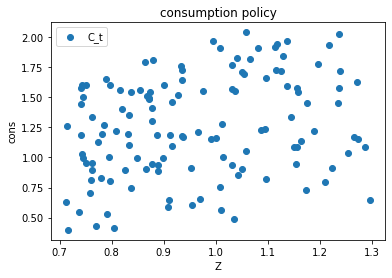

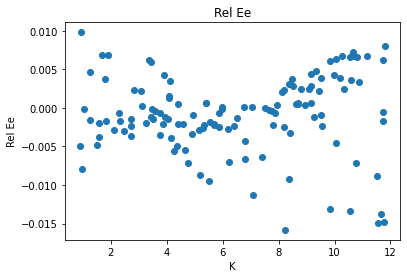

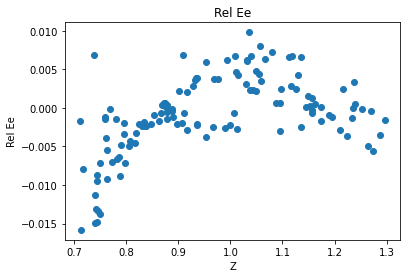

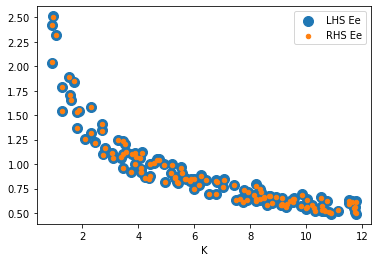

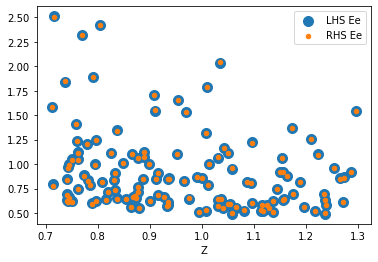

#=================================================================
episode = 5000, loss [log10] = -4.8390984535217285


#=================================================================
episode = 6000, loss [log10] = -4.976903915405273


#=================================================================
episode = 7000, loss [log10] = -5.131266117095947


#=================================================================
episode = 8000, loss [log10] = -5.174245357513428


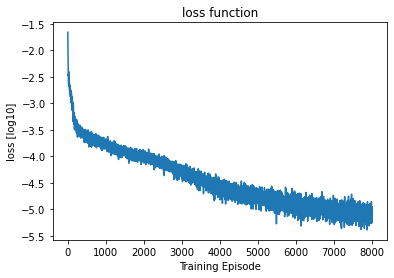

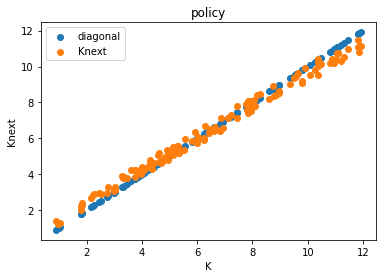

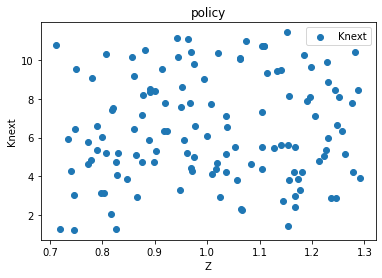

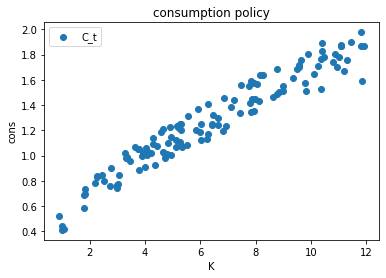

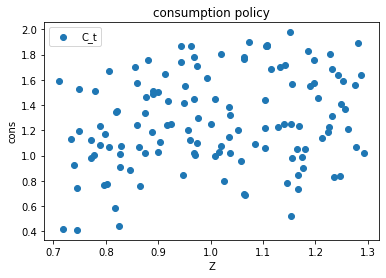

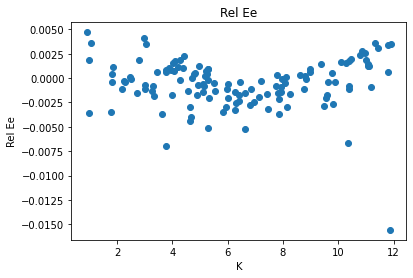

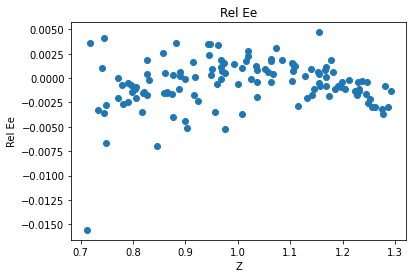

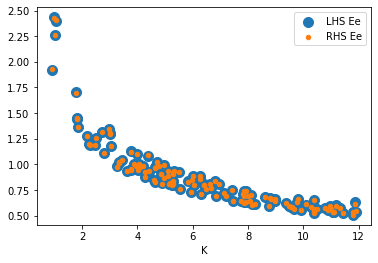

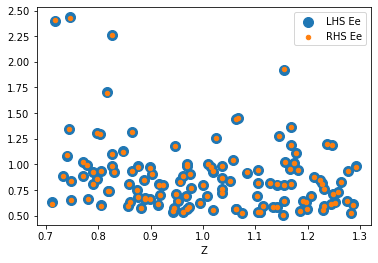

#=================================================================
episode = 9000, loss [log10] = -5.227747917175293


#=================================================================
episode = 10000, loss [log10] = -5.1854424476623535


#=================================================================
episode = 11000, loss [log10] = -5.256743907928467


#=================================================================
episode = 12000, loss [log10] = -5.439003944396973


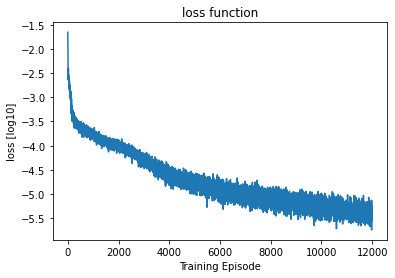

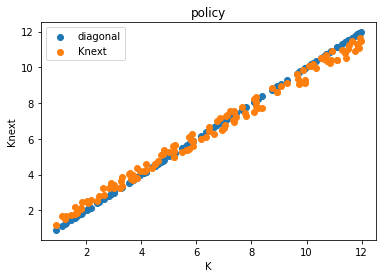

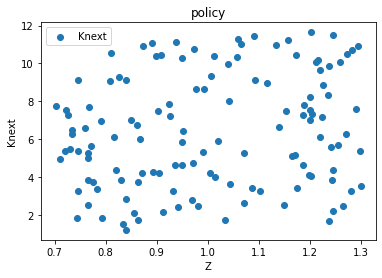

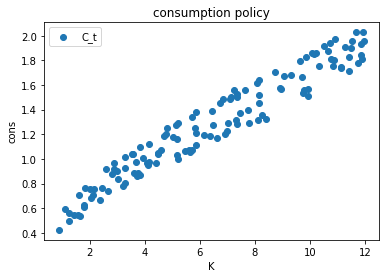

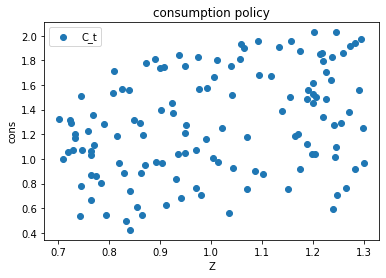

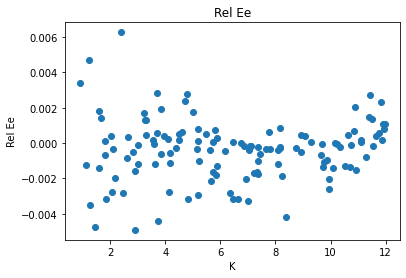

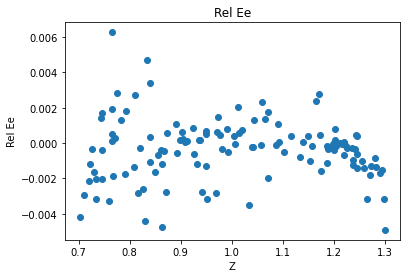

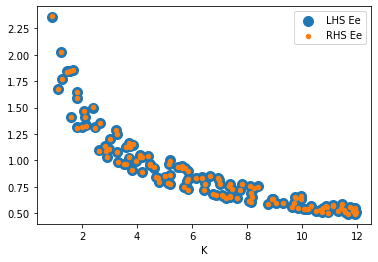

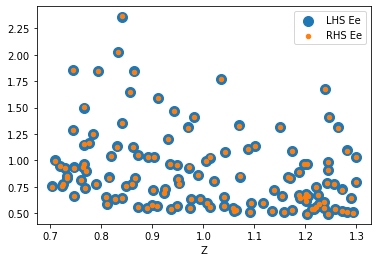

#=================================================================
episode = 13000, loss [log10] = -5.450650691986084


#=================================================================
episode = 14000, loss [log10] = -5.602588176727295


#=================================================================
episode = 15000, loss [log10] = -5.537710189819336


#=================================================================
episode = 16000, loss [log10] = -5.589004993438721


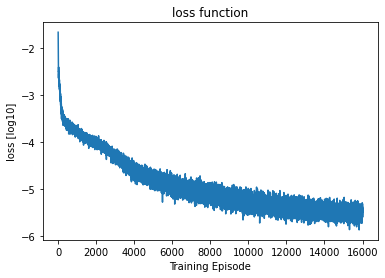

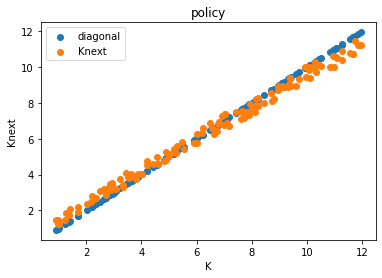

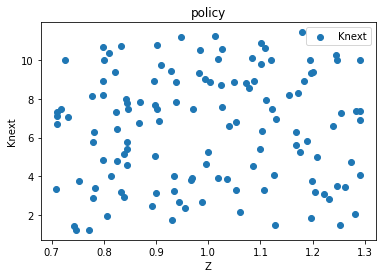

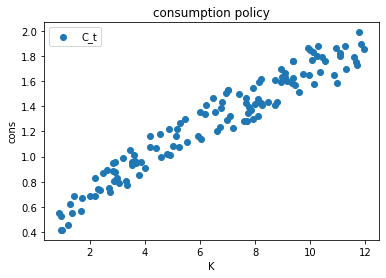

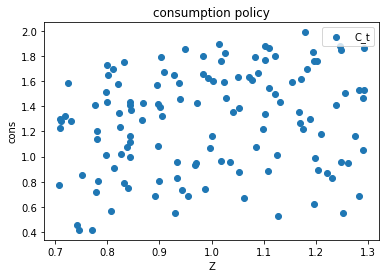

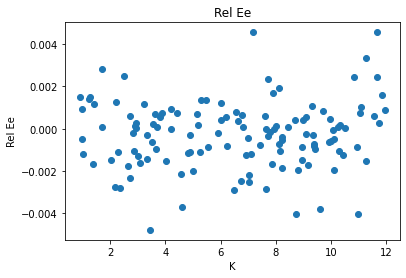

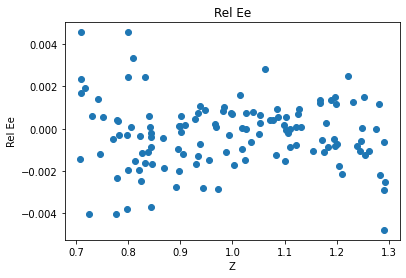

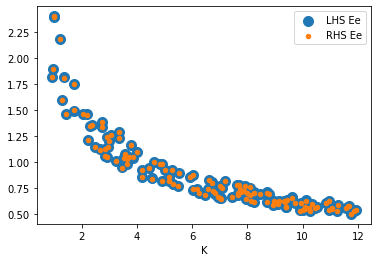

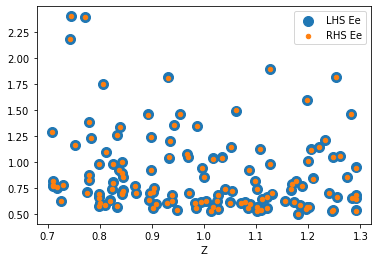

#=================================================================
episode = 17000, loss [log10] = -5.49631404876709


#=================================================================
episode = 18000, loss [log10] = -5.557910919189453


#=================================================================
episode = 19000, loss [log10] = -5.500194549560547


#=================================================================
episode = 20000, loss [log10] = -5.482391834259033


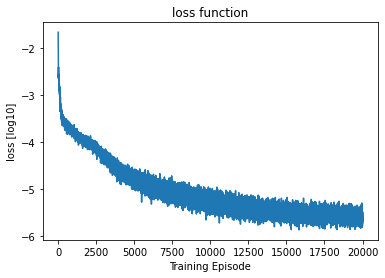

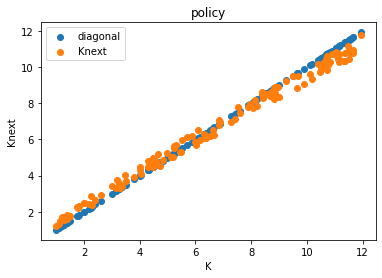

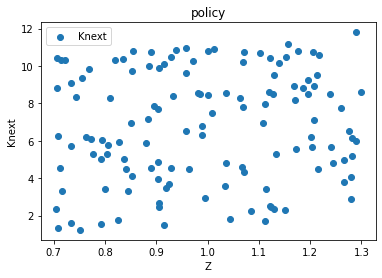

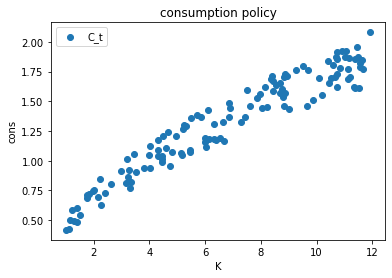

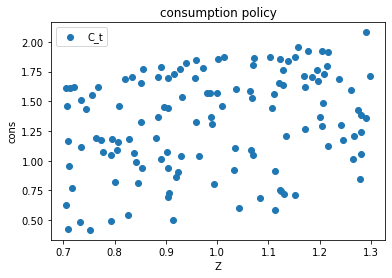

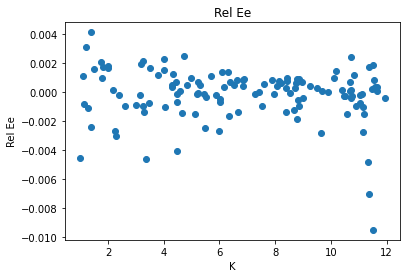

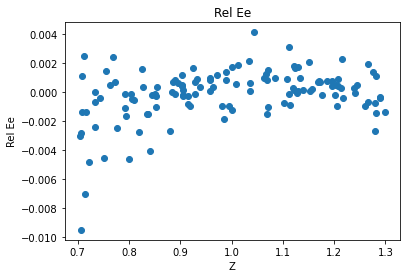

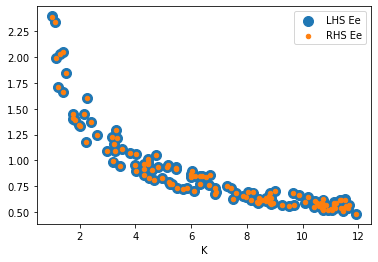

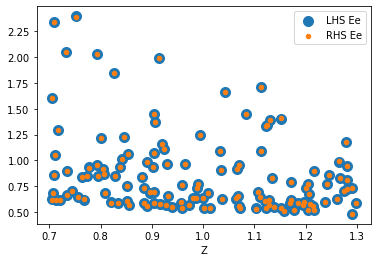

In [18]:
# Keep results for plotting
train_loss = []

num_episodes = EP_UNIFORM
n_data_per_epi = 128
z_lb = 0.7
z_ub = 1.3
k_lb = 0.9
k_ub = 12.0


for ep in range(num_episodes):
    # generate training data
    X = get_training_data(z_lb, z_ub, k_lb, k_ub, n_data_per_epi)

    # compute loss and gradients
    loss, grads = grad(X, nn)
    
    # apply gradients
    optimizer.apply_gradients(zip(grads, nn.trainable_variables))
    
    # record loss
    train_loss.append(loss.numpy())
    
    # print progress
    if ep % int(0.05 * num_episodes) == 0:
        print("#=================================================================")
        print("episode = {}, loss [log10] = {}".format(ep, np.log10(loss.numpy())))
        
    if ep % int(0.2 * num_episodes) == 0 or ep == num_episodes - 1:
        cost, errREE, C_t, K_tplus1, r_t, LHS, RHS = compute_cost(X, nn)
        
        plt.title("loss function")
        plt.plot(np.log10(np.array(train_loss)))
        plt.xlabel("Training Episode")
        plt.ylabel("loss [log10]")
        plt.show()
        plt.close()

        plt.title("policy")
        plt.xlabel("K")
        plt.ylabel("Knext")
        plt.scatter(X[:, 1], X[:, 1], label = "diagonal")
        plt.scatter(X[:, 1], K_tplus1[:, 0], label = "Knext")
        plt.legend()
        plt.show()
        plt.close()

        plt.title("policy")
        plt.xlabel("Z")
        plt.ylabel("Knext")
        plt.scatter(X[:, 0], K_tplus1[:, 0], label = "Knext")
        plt.legend()
        plt.show()
        plt.close()

        plt.title("consumption policy")
        plt.xlabel("K")
        plt.ylabel("cons")
        plt.scatter(X[:, 1], C_t[:, 0], label="C_t")
        plt.legend()
        plt.show()
        plt.close()

        plt.title("consumption policy")
        plt.xlabel("Z")
        plt.ylabel("cons")
        plt.scatter(X[:, 0], C_t[:, 0], label="C_t")
        plt.legend()
        plt.show()
        plt.close()

        plt.title("Rel Ee")
        plt.xlabel("K")
        plt.ylabel("Rel Ee")
        plt.scatter(X[:, 1], errREE[:, 0], label="REE")
        plt.show()
        plt.close()
       
        plt.title("Rel Ee")
        plt.xlabel("Z")
        plt.ylabel("Rel Ee")
        plt.scatter(X[:, 0], errREE[:, 0], label="REE")
        plt.show()
        plt.close()
        
        plt.xlabel("K")
        plt.scatter(X[:, 1], LHS[:, 0], s = 100, label="LHS Ee")
        plt.scatter(X[:, 1], RHS[:, 0], s = 20, label="RHS Ee")
        plt.legend()
        plt.show()
        plt.close()
        
        plt.xlabel("Z")
        plt.scatter(X[:, 0], LHS[:, 0], s = 100, label="LHS Ee")
        plt.scatter(X[:, 0], RHS[:, 0], s = 20, label="RHS Ee")
        plt.legend()
        plt.show()
        plt.close()

## Simulating the model from the policy
Given a policy function, we can simulate the model forward.
Say we start out with a state $\mathbf{X}_t=[z_t, K_t]$.  
We can use the neural network to obtain $K_{t+1} = Y_t \cdot \mathcal{N}(\mathbf{X}_t)$.  
Then, we can draw a random innovation $\epsilon_t\sim N(0, 1)$ using a pseudo-random number generator and obtain $Z_{t+1}=\rho Z_t + \sigma \epsilon_t$.  
Now we have $\mathbf{X}_{t+1}=[Z_{t+1}, K_{t+1}]$.  
We can repeat the same procedure to obtain $\mathbf{X}_{t+2}$ and so on and so forth.  
Next, we will implement a function that takes a batch of states, a batch of innovations, and the neural network and then simulates the states one period forward based on  the policy encoded by the neural network.  
Afterward, we will write a second function to simulate longer sequences.

In [19]:
@tf.function
def simulate_single_step(X_t, eps_tplus1, nn):
    # function simulates the economy one step forward based on the neural network policy and the innovation
    
    n_data = X_t.shape[0] # number of states is on the axis 0
    dim_state = X_t.shape[1] # dimensionality of the state is on axis 1
    
    # read out the state
    Z_t = X_t[:, 0 : 1]
    K_t = X_t[:, 1 : 2]
    
    # compute output today
    Y_t = Z_t * K_t ** alpha
    
    # use the neural network to predict the savings rate
    s_t = nn(X_t)
    
    # get the implied capital in the next period
    K_tplus1 = (1. - delta) * K_t + Y_t * s_t
    
    # get tfp in the next period
    Z_tplus1 = tf.exp(rho_tfp * tf.math.log(Z_t) + sigma_tfp * eps_tplus1)    
    
    # construct the next step
    X_tplus1 = tf.concat([Z_tplus1, K_tplus1],axis = 1)
    
    return X_tplus1

def sim_periods(X_start, nn, num_periods):
    n_tracks = X_start.shape[0] # number of states is on the axis 0
    dim_state = X_start.shape[1] # dimensionality of the state is on axis 1
    
    # create an empty array to store the states
    X_simulation = np.empty((num_periods, n_tracks, dim_state)) # 0 axis: time period, 1 axis: the different trajectories, 2 axis: the different state variables
    
    # draw random innovation
    eps = tf.random.normal((num_periods, n_tracks), dtype = tf.float32)
    
    # set starting state
    X_simulation[0, :, :] = X_start
    
    X_old = X_start
    
    # simulate the periods
    for t in range(1, num_periods):
        eps_use = eps[t, :, tf.newaxis] # newaxis makes sure the shape is n_tracks x 1
        
        X_new = simulate_single_step(X_old, eps_use, nn)
        
        X_simulation[t, :, :] = X_new
        
        X_old = X_new
        
    return X_simulation

In [20]:
# let's pick a starting state
X_start = np.array([[0.5 * (z_ub + z_lb), 0.5 * (k_ub + k_lb)]], dtype = np.float32)

# and simulate it some periods forward using the neural network
num_periods = 200 
X_simulation = sim_periods(X_start, nn, num_periods)

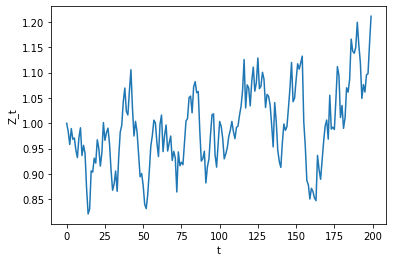

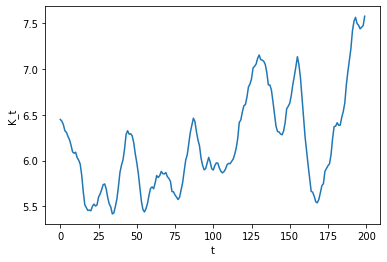

In [21]:
plt.plot(X_simulation[:, 0, 0])
plt.xlabel("t")
plt.ylabel("Z_t")
plt.show()

plt.plot(X_simulation[:, 0, 1])
plt.xlabel("t")
plt.ylabel("K_t")
plt.show()

Like often in macro, the two variables seem to be moving together, so let's try to get a sense of the **ergodic distribution** of the state space.

In [22]:
num_periods = 10000

# we simulate more periods
X_simulation = sim_periods(X_start, nn, num_periods)

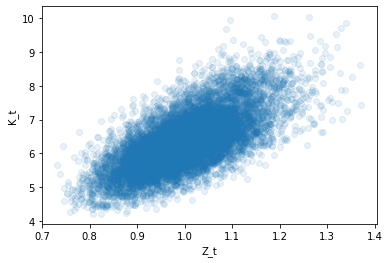

In [23]:
# we make a scatter plot for the two state-variables
plt.scatter(X_simulation[:, 0, 0], X_simulation[:, 0, 1], alpha = 0.1)
plt.xlabel("Z_t")
plt.ylabel("K_t")
plt.show()

As we can see the model essentially lives on a cloud around the diagonal.  
The model never reaches states with extremely low productivity and extremely high capital or states with extremely high  productivity and extremely low capital.  
This means all the effort we spent training the neural network in these areas (top left and bottom right) was essentially in vain.  
With more than two variables, this issues becomes exponentially more extreme (see [Maliar et al. (2011)](https://www.sciencedirect.com/science/article/pii/S0165188910002186) for more information on this topic).  
Moreover, we may not even know where the cloud will be, since it depends on the very policy we want to solve for!  
Hence, it would be very good if we could simultaneously learn the policy on the cloud of interest while also moving the cloud as we update the policies.  
[Azinovic et al. (2022)](https://onlinelibrary.wiley.com/doi/full/10.1111/iere.12575) address this issue by iterating between **simulating new states** from the neural network policy and then **training the neural network** on those simulated states. This is what we will do next.

## Iterating between training an simulation
What changes compared to our previous approach? Only how we sample the states! 

Instead of drawing exogenously from a given interval, we simulate the model using  the policy encoded in the neural network. 
Since neural networks can be very efficiently executed on batches, and to increase independence of the data, we simulate more than one track in parallel, but each for a shorter period of times. For example, we can get 1000  simulated states by either simulating one track for 1000 periods of 100 tracks for 10 periods, the latter will be much faster.  

In [24]:
def get_training_data_simulation(X_start, nn, n_periods):
    n_tracks = X_start.shape[0]
    n_dim = X_start.shape[1]
    
    # we simulate the model
    X_simulation = sim_periods(X_start, nn, n_periods)
    
    # we read out the last state (so that we can use it as starting poit for the next simulation)
    X_end = np.float32(X_simulation[-1, :, :])
    
    # we reshape the data into (n_tracks * n_periods) x 2 array 
    X_training = np.float32(np.reshape(X_simulation, (n_tracks * n_periods, n_dim)))
    
    return X_training, X_end 

In [25]:
# let's try
# let's get a new neural network
nn = keras.Sequential([
    keras.layers.Dense(num_hidden1, activation='relu', input_shape=(num_input,)),
    keras.layers.Dense(num_hidden2, activation='relu'),
    keras.layers.Dense(num_output, activation='sigmoid')
])


n_tracks = 50
n_periods = 3
print("n_tracks = ", n_tracks)
print("n_periods = ", n_periods)

# start from a random state
X_start = get_training_data(z_lb, z_ub, k_lb, k_ub, n_tracks)
print("X_start.shape = ", X_start.shape)

print("With every simulation we get", n_tracks * n_periods, "new states")

X_training, X_end = get_training_data_simulation(X_start, nn, n_periods)
print("X_training.shape = ", X_training.shape)
print("X_end.shape = ", X_end.shape)

learning_rate = 0.0001
print("learning_rate = ", learning_rate)
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

print(compute_cost(X_start, nn)[0])

n_tracks =  50
n_periods =  3
X_start.shape =  (50, 2)
With every simulation we get 150 new states
X_training.shape =  (150, 2)
X_end.shape =  (50, 2)
learning_rate =  0.0001


tf.Tensor(0.0024712598, shape=(), dtype=float32)


The only thing that changes in the training loop is how we sample the data.

n_tracks =  50
n_periods =  3


#=================================================================
episode = 0, loss [log10] = -2.6850035190582275


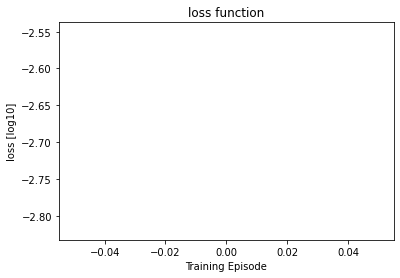

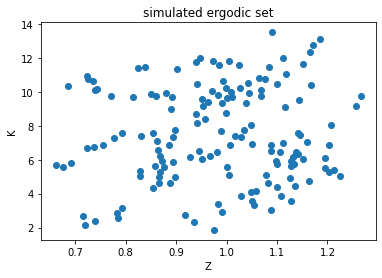

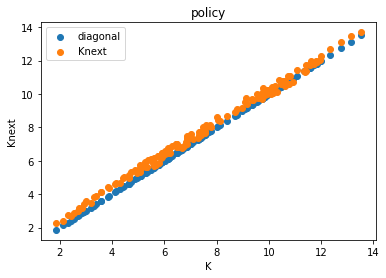

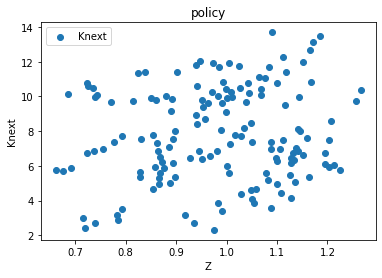

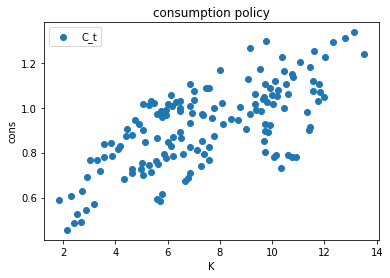

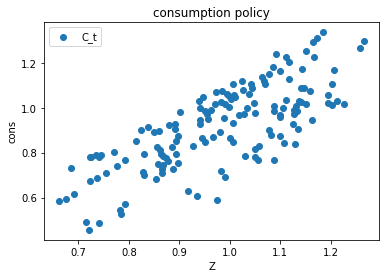

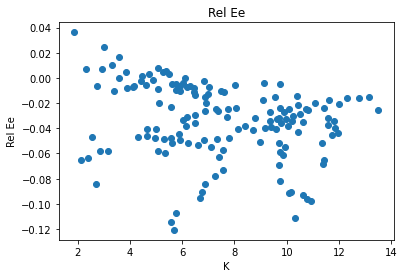

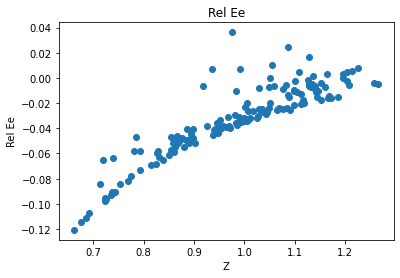

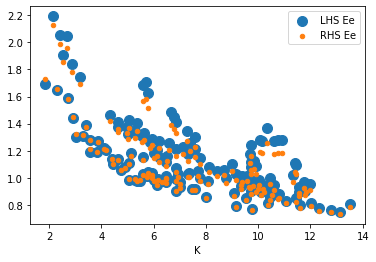

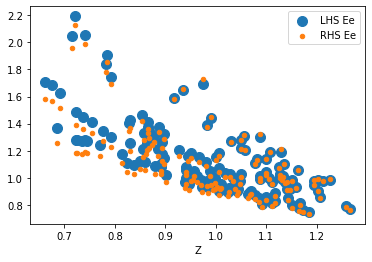

#=================================================================
episode = 100, loss [log10] = -4.130701065063477


#=================================================================
episode = 200, loss [log10] = -3.884157419204712


#=================================================================
episode = 300, loss [log10] = -4.202012538909912


#=================================================================
episode = 400, loss [log10] = -4.0461859703063965


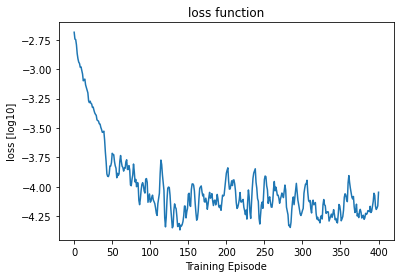

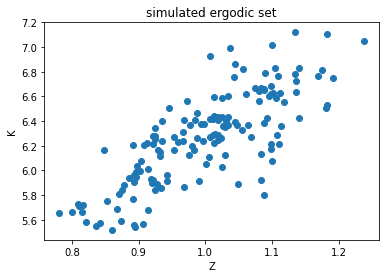

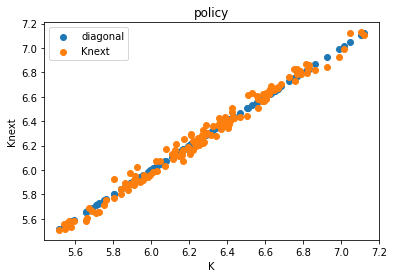

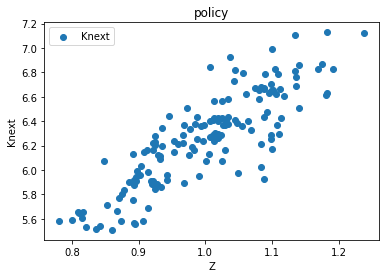

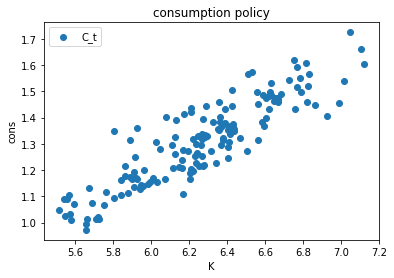

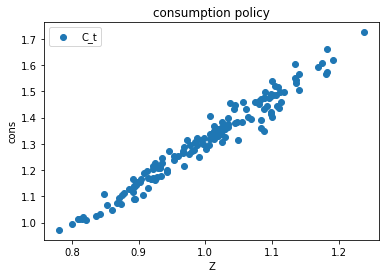

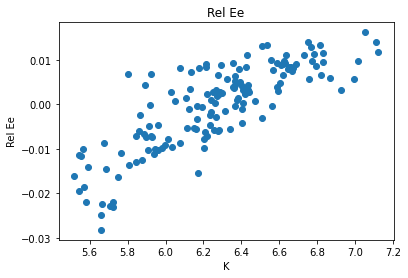

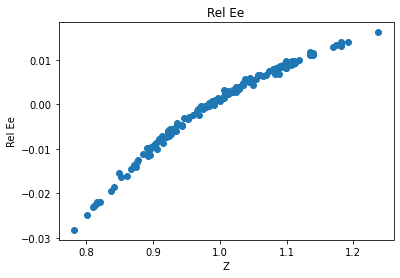

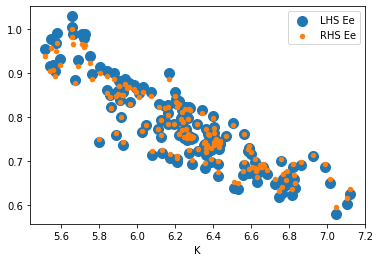

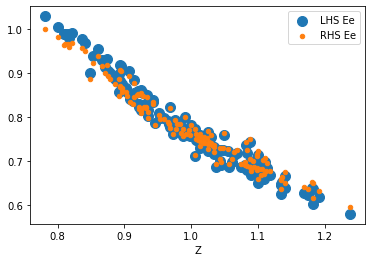

#=================================================================
episode = 500, loss [log10] = -4.137580394744873


#=================================================================
episode = 600, loss [log10] = -4.115234375


#=================================================================
episode = 700, loss [log10] = -4.115781307220459


#=================================================================
episode = 800, loss [log10] = -4.1600341796875


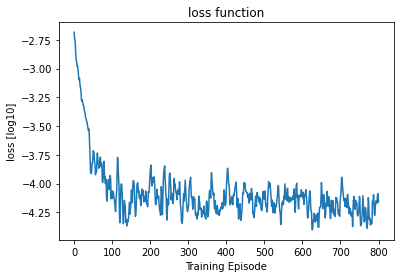

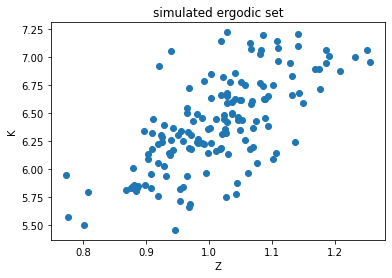

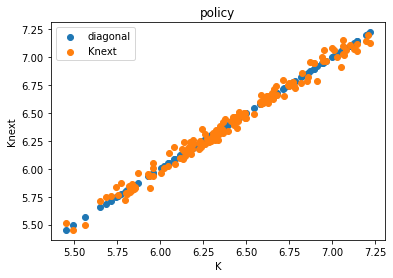

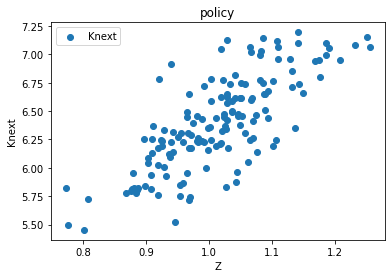

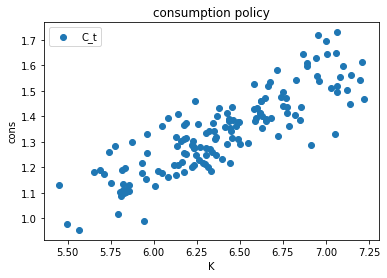

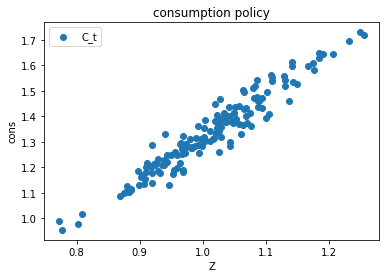

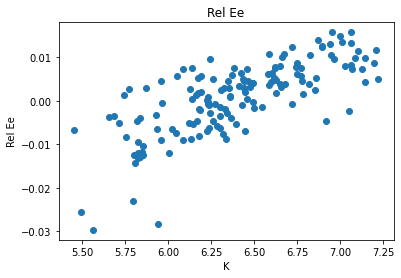

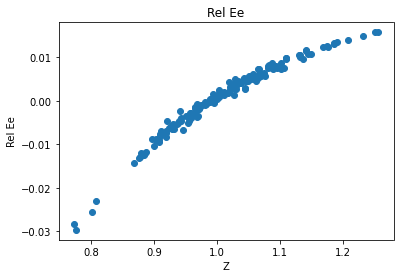

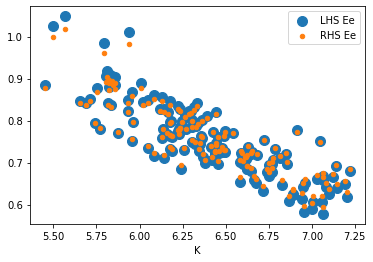

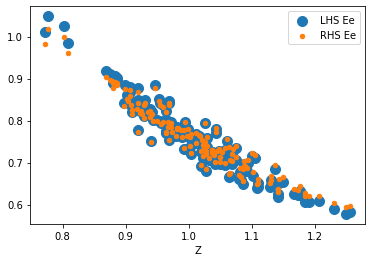

#=================================================================
episode = 900, loss [log10] = -4.3113813400268555


#=================================================================
episode = 1000, loss [log10] = -4.304412364959717


#=================================================================
episode = 1100, loss [log10] = -4.289432048797607


#=================================================================
episode = 1200, loss [log10] = -4.132328987121582


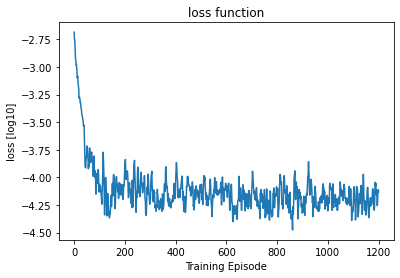

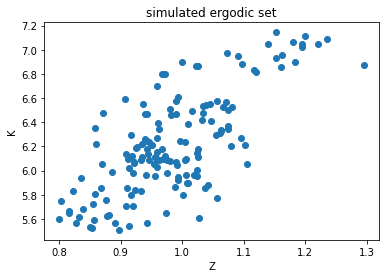

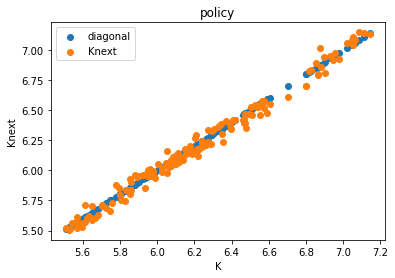

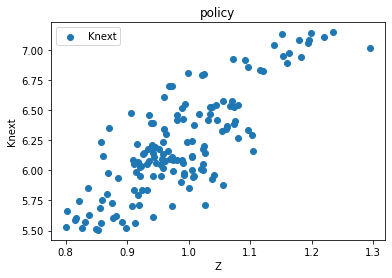

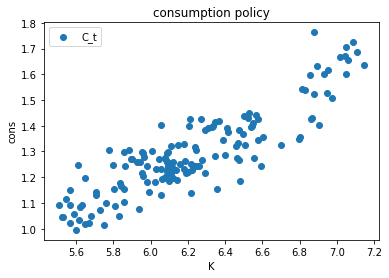

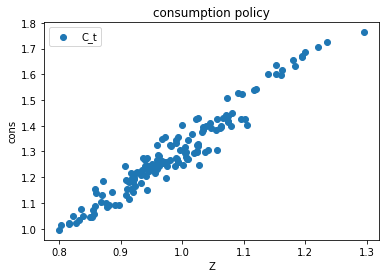

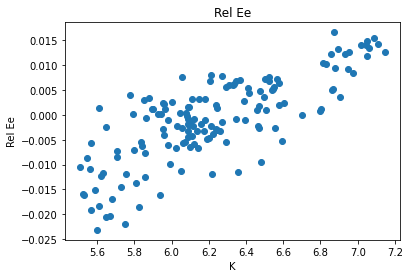

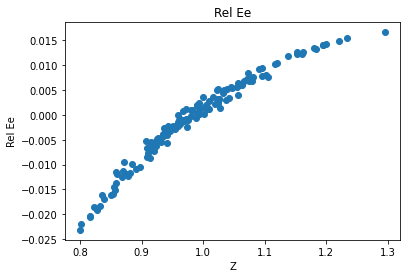

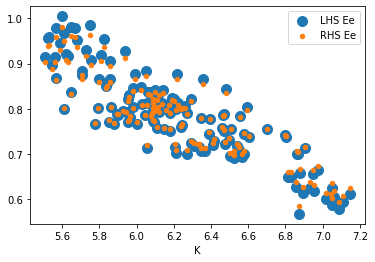

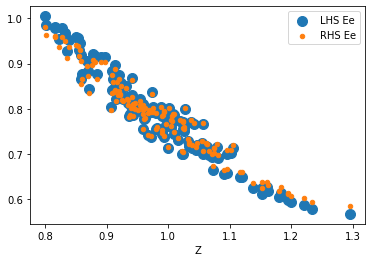

#=================================================================
episode = 1300, loss [log10] = -4.276113033294678


#=================================================================
episode = 1400, loss [log10] = -4.31005334854126


#=================================================================
episode = 1500, loss [log10] = -4.190093517303467


#=================================================================
episode = 1600, loss [log10] = -4.2320637702941895


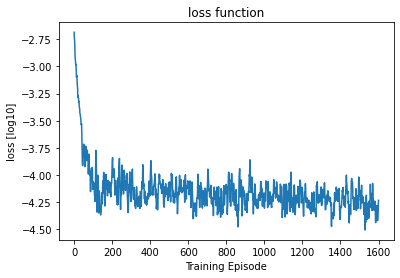

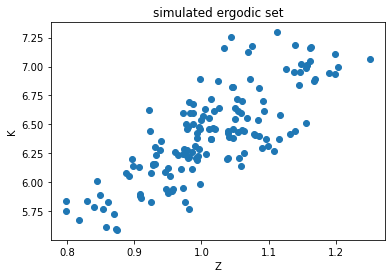

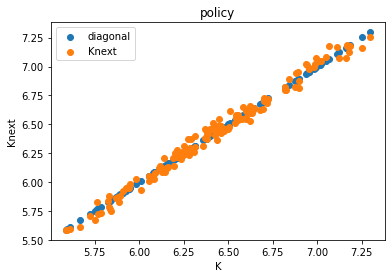

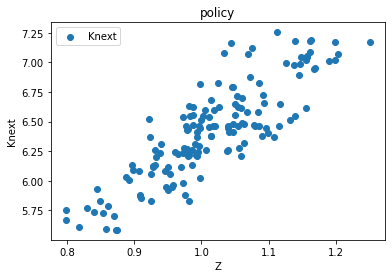

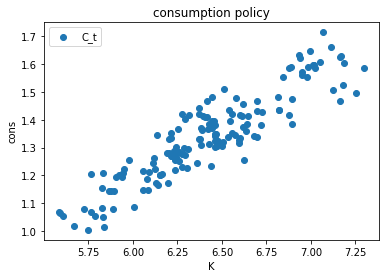

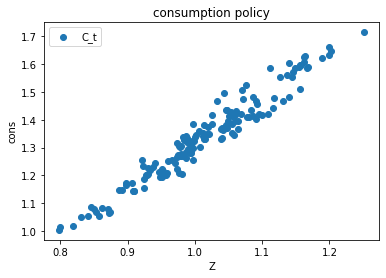

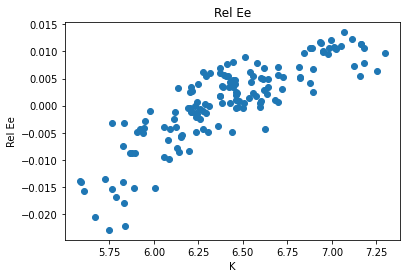

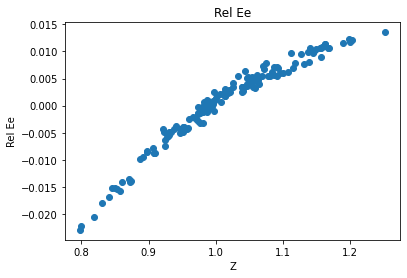

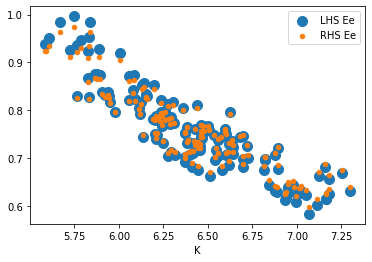

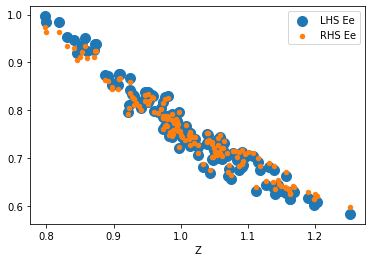

#=================================================================
episode = 1700, loss [log10] = -4.170180320739746


#=================================================================
episode = 1800, loss [log10] = -4.288200378417969


#=================================================================
episode = 1900, loss [log10] = -4.369623184204102


#=================================================================
episode = 2000, loss [log10] = -4.533426284790039


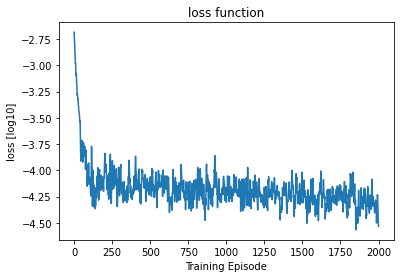

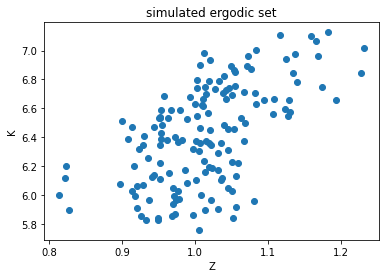

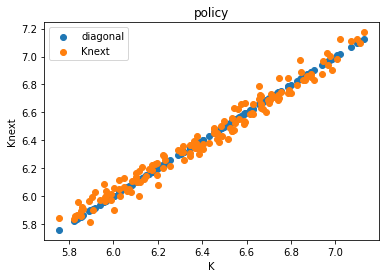

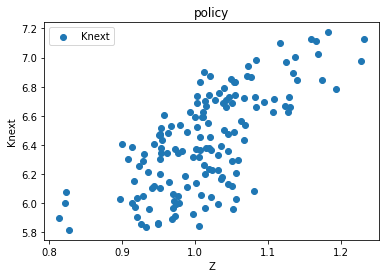

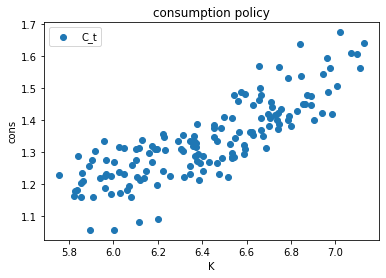

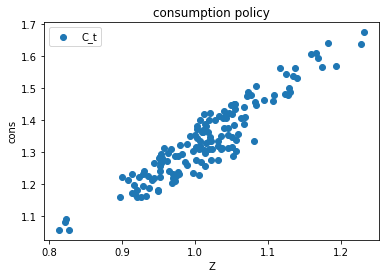

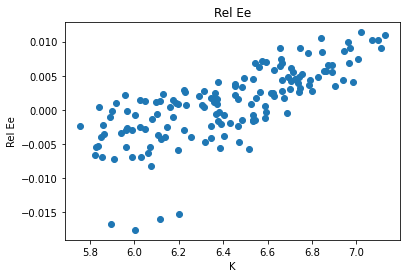

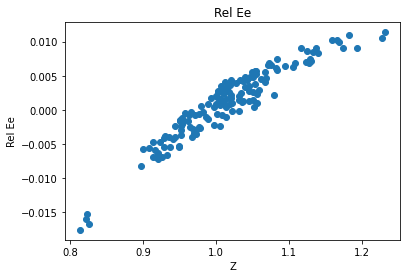

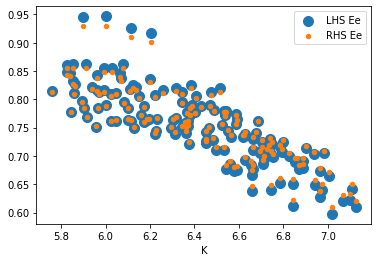

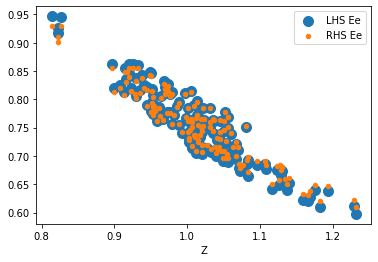

In [26]:
# Keep results for plotting
train_loss = []

num_episodes = EP_SIM

# initialize X_start
X_start = X_end
print("n_tracks = ", X_start.shape[0])
print("n_periods = ", n_periods)

for ep in range(num_episodes):
    # generate training data, now by sampling
    X, X_end = get_training_data_simulation(X_start, nn, n_periods)

    # update X_start
    X_start = X_end
    
    # compute loss and gradients
    loss, grads = grad(X, nn)

    # apply gradients
    optimizer.apply_gradients(zip(grads, nn.trainable_variables))
    
    # record loss
    train_loss.append(loss.numpy())
    
    # print progress
    if ep % int(0.05 * num_episodes) == 0:
        print("#=================================================================")
        print("episode = {}, loss [log10] = {}".format(ep, np.log10(loss.numpy())))
        
    if ep % int(0.2 * num_episodes) == 0 or ep == num_episodes - 1:
        cost, errREE, C_t, K_tplus1, r_t, LHS, RHS = compute_cost(X, nn)
        
        plt.title("loss function")
        plt.plot(np.log10(np.array(train_loss)))
        plt.xlabel("Training Episode")
        plt.ylabel("loss [log10]")
        plt.show()
        plt.close()
        
        plt.title("simulated ergodic set")
        plt.scatter(X[:, 0], X[:, 1])
        plt.xlabel("Z")
        plt.ylabel("K")
        plt.show()
        plt.close()
        
        
        plt.title("policy")
        plt.xlabel("K")
        plt.ylabel("Knext")
        plt.scatter(X[:, 1], X[:, 1], label = "diagonal")
        plt.scatter(X[:, 1], K_tplus1[:, 0], label = "Knext")
        plt.legend()
        plt.show()
        plt.close()

        plt.title("policy")
        plt.xlabel("Z")
        plt.ylabel("Knext")
        plt.scatter(X[:, 0], K_tplus1[:, 0], label = "Knext")
        plt.legend()
        plt.show()
        plt.close()

        plt.title("consumption policy")
        plt.xlabel("K")
        plt.ylabel("cons")
        plt.scatter(X[:, 1], C_t[:, 0], label="C_t")
        plt.legend()
        plt.show()
        plt.close()

        plt.title("consumption policy")
        plt.xlabel("Z")
        plt.ylabel("cons")
        plt.scatter(X[:, 0], C_t[:, 0], label="C_t")
        plt.legend()
        plt.show()
        plt.close()

        plt.title("Rel Ee")
        plt.xlabel("K")
        plt.ylabel("Rel Ee")
        plt.scatter(X[:, 1], errREE[:, 0], label="REE")
        plt.show()
        plt.close()
       
        plt.title("Rel Ee")
        plt.xlabel("Z")
        plt.ylabel("Rel Ee")
        plt.scatter(X[:, 0], errREE[:, 0], label="REE")
        plt.show()
        plt.close()
        
        plt.xlabel("K")
        plt.scatter(X[:, 1], LHS[:, 0], s = 100, label="LHS Ee")
        plt.scatter(X[:, 1], RHS[:, 0], s = 20, label="RHS Ee")
        plt.legend()
        plt.show()
        plt.close()
        
        plt.xlabel("Z")
        plt.scatter(X[:, 0], LHS[:, 0], s = 100, label="LHS Ee")
        plt.scatter(X[:, 0], RHS[:, 0], s = 20, label="RHS Ee")
        plt.legend()
        plt.show()
        plt.close()

**Final but important remark on simulation based methods:** Without a question, simulation based methods offer a huge advantage, exponentially so in high dimensions. However, they also introduce some fragility into the learning process, since the distribution of the training data changes when the policy changes. On the one hand, this is exactly what we want, but on the other hand, it can make training unstable when moving too quikly to unseen data. Hence some parameters may have to be optimized more carefully, **especially the learning rate**, so that the data distribution is not changing to quickly. Depending on the model, we may also need to take care of the fact that in the beginning of training the neural network policies are random and may hence predict infeasible states (like negative aggregate capital), which make useful learning impossible. 
[Azinovic et al. (2022)](https://onlinelibrary.wiley.com/doi/full/10.1111/iere.12575) address some of these points in the appendices and [Azinovic and Žemlička (2023)](https://arxiv.org/abs/2303.14802) introduce market-clearing neural network architectures, as well as a procedure to introduce multiple assets, which stabilized training.

## Cross-check 2: side-experiment vs the analytical solution under full depreciation

When \(\delta = 1\) and \(u(C) = \ln C\), the stochastic Brock-Mirman model with log utility admits a **closed-form policy** for *any* productivity process:
$$K_{t+1} = \alpha\beta\, z_t\, K_t^{\alpha}, \qquad C_t = (1-\alpha\beta)\, z_t\, K_t^{\alpha}.$$
We now re-train a fresh network with **the same autodiff loss**, but with \(\delta = 1\) and a smaller domain so training converges quickly. The trained policy must match the closed form on a 2-D grid in \((z, K)\).

(This complements cross-check 1: cross-check 1 verified that the *loss* equals the textbook Euler equation; cross-check 2 verifies that minimizing it actually recovers the *true policy* in a case where we know the answer.)

In [27]:
# --- Side-experiment: full depreciation, where the analytical policy is known ---
delta_full = 1.0   # full depreciation (analytical regime)
sigma_se   = 0.04  # keep some productivity noise -- the analytical formula holds for any z process

# Fresh small network (faster training; same architecture as before)
tf.random.set_seed(0)
nn_se = keras.Sequential([
    keras.layers.Dense(50, activation='relu', input_shape=(2,)),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid'),
])

# Same Pi pattern, but with delta_full
def Pi_se(K_in, K_out, z_in):
    Y = z_in * K_in ** alpha
    C = Y + (1.0 - delta_full) * K_in - K_out
    return tf.math.log(C)

x_int_se = x_int_norm * sigma_se

@tf.function
def compute_cost_se(X, nn):
    Z_t = X[:, 0:1]
    K_t = X[:, 1:2]
    Y_t = Z_t * K_t ** alpha
    s_t = nn(X)
    K_tp1 = (1.0 - delta_full) * K_t + Y_t * s_t
    with tf.GradientTape() as t1:
        t1.watch(K_tp1)
        pi_t = Pi_se(K_t, K_tp1, Z_t)
    dPi_dKout = t1.gradient(pi_t, K_tp1)
    expectation = tf.zeros_like(K_t)
    for i in range(n_int):
        Z_tp1 = tf.exp(rho_tfp * tf.math.log(Z_t) + x_int_se[i])
        X_tp1 = tf.concat([Z_tp1, K_tp1], axis=1)
        Y_tp1 = Z_tp1 * K_tp1 ** alpha
        s_tp1 = nn(X_tp1)
        K_tp2 = (1.0 - delta_full) * K_tp1 + Y_tp1 * s_tp1
        with tf.GradientTape() as t2:
            t2.watch(K_tp1)
            pi_tp1 = Pi_se(K_tp1, K_tp2, Z_tp1)
        dPi_dKin = t2.gradient(pi_tp1, K_tp1)
        expectation = expectation + w_int[i] * dPi_dKin
    res = dPi_dKout + beta * expectation
    return tf.reduce_mean(res ** 2)

opt_se = tf.keras.optimizers.Adam(learning_rate=1e-3)

@tf.function
def step_se(X):
    with tf.GradientTape() as g:
        loss = compute_cost_se(X, nn_se)
    grads = g.gradient(loss, nn_se.trainable_variables)
    opt_se.apply_gradients(zip(grads, nn_se.trainable_variables))
    return loss

print("Training side-experiment network (3000 episodes, delta=1)...")
for ep in range(3001):
    Z = tf.random.uniform([128, 1], 0.7, 1.3)
    K = tf.random.uniform([128, 1], 0.10, 1.0)
    X = tf.concat([Z, K], axis=1)
    L = step_se(X)
    if ep % 500 == 0:
        print(f"  episode {ep:5d}, loss [log10] = {np.log10(L.numpy()):.3f}")


Training side-experiment network (3000 episodes, delta=1)...


  episode     0, loss [log10] = 0.005


  episode   500, loss [log10] = -4.567


  episode  1000, loss [log10] = -5.179


  episode  1500, loss [log10] = -5.590


  episode  2000, loss [log10] = -5.918


  episode  2500, loss [log10] = -5.939


  episode  3000, loss [log10] = -6.140


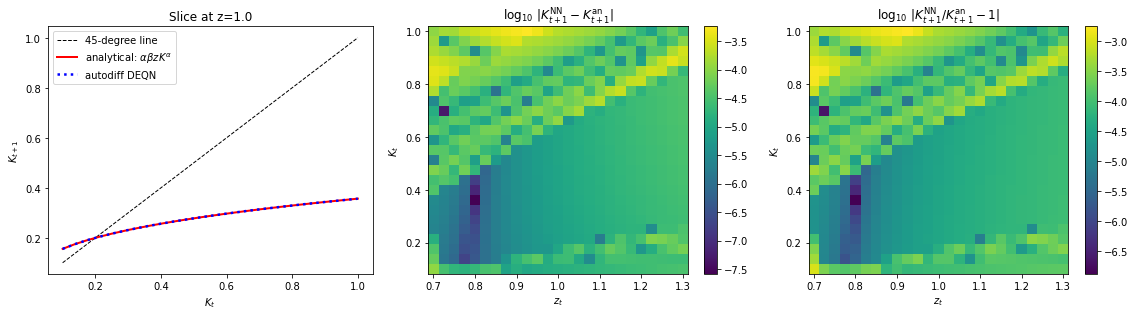


Full-depreciation comparison on 25 x 25 grid in (z, K) = [0.7,1.3] x [0.1,1.0]:
  max  absolute error : 5.722e-04
  mean absolute error : 4.486e-05
  max  relative error : 1.736e-03
  mean relative error : 1.540e-04
  --> the autodiff Euler equation indeed converges to the analytical policy.


In [28]:
# Compare trained policy against analytical K' = alpha*beta*z*K^alpha on a 2-D grid
zz = np.linspace(0.7, 1.3, 25)
kk = np.linspace(0.10, 1.0, 25)
ZZ, KK = np.meshgrid(zz, kk)
X_eval = tf.constant(np.column_stack([ZZ.ravel(), KK.ravel()]), dtype=tf.float32)
s_eval  = nn_se(X_eval).numpy().flatten()
Yeval   = (ZZ.ravel()) * (KK.ravel()) ** alpha
Kp_nn   = (1.0 - delta_full) * KK.ravel() + Yeval * s_eval
Kp_an   = alpha * beta * ZZ.ravel() * (KK.ravel()) ** alpha

abs_err = np.abs(Kp_nn - Kp_an)
rel_err = abs_err / np.abs(Kp_an)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Slice at z=1: K -> K'
mask_z1 = np.isclose(ZZ.ravel(), zz[np.argmin(np.abs(zz - 1.0))])
axes[0].plot(KK.ravel()[mask_z1], KK.ravel()[mask_z1], 'k--', lw=1, label='45-degree line')
axes[0].plot(KK.ravel()[mask_z1], Kp_an[mask_z1], 'r-',  lw=2,   label=r'analytical: $\alpha\beta z K^{\alpha}$')
axes[0].plot(KK.ravel()[mask_z1], Kp_nn[mask_z1], 'b:',  lw=2.5, label='autodiff DEQN')
axes[0].set_xlabel(r'$K_t$'); axes[0].set_ylabel(r'$K_{t+1}$')
axes[0].set_title('Slice at z=1.0'); axes[0].legend()

# Heatmap of abs error
im1 = axes[1].pcolormesh(ZZ, KK, np.log10(abs_err.reshape(ZZ.shape) + 1e-15), shading='auto', cmap='viridis')
axes[1].set_xlabel(r'$z_t$'); axes[1].set_ylabel(r'$K_t$')
axes[1].set_title(r'$\log_{10}\,|K^{\rm NN}_{t+1} - K^{\rm an}_{t+1}|$')
plt.colorbar(im1, ax=axes[1])

# Heatmap of rel error
im2 = axes[2].pcolormesh(ZZ, KK, np.log10(rel_err.reshape(ZZ.shape) + 1e-15), shading='auto', cmap='viridis')
axes[2].set_xlabel(r'$z_t$'); axes[2].set_ylabel(r'$K_t$')
axes[2].set_title(r'$\log_{10}\,|K^{\rm NN}_{t+1}/K^{\rm an}_{t+1} - 1|$')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout(); plt.show()

print(f"\nFull-depreciation comparison on 25 x 25 grid in (z, K) = [0.7,1.3] x [0.1,1.0]:")
print(f"  max  absolute error : {abs_err.max():.3e}")
print(f"  mean absolute error : {abs_err.mean():.3e}")
print(f"  max  relative error : {rel_err.max():.3e}")
print(f"  mean relative error : {rel_err.mean():.3e}")
print(f"  --> the autodiff Euler equation indeed converges to the analytical policy.")


## Takeaway

- We solved the **same stochastic Brock-Mirman model as notebook 02** without ever writing the FOC or invoking the envelope theorem on paper. The user only writes the three-argument primitive `Pi(K_in, K_out, z_in)`; both derivatives come out of `tf.GradientTape`.
- **Cross-check 1** confirmed that the autodiff stochastic Euler residual is numerically identical to the hand-derived residual at machine precision.
- **Cross-check 2** confirmed that, when an analytical solution is available (full depreciation), the autodiff DEQN recovers the closed-form policy $K_{t+1} = \alpha\beta z_t K_t^{\alpha}$ on a dense grid.
- The pattern $\,\partial_2 \Pi + \beta\,\mathbb{E}[\partial_1 \Pi] = 0\,$ (differentiate in the *choice* slot, plus $\beta\times$expected derivative in the *state* slot) generalizes verbatim to richer models: arbitrary utility, multi-good production, occasionally binding constraints (with a Fischer-Burmeister wrap), and high-dimensional state spaces (as in days 3-7 of the course).